In [197]:
%load_ext autoreload
%autoreload 2

import os

subj = "sleep-edf/Subj6"

exp = "exp_reduced_flow"
os.makedirs(f"{subj}/{exp}", exist_ok = True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [198]:
import typing

import mne
import numpy
import pandas
import IPython.display
import sklearn.metrics
import sklearn.preprocessing
import sklearn.decomposition
import matplotlib.pyplot as plt

import SDA.topology
import SDA.analytics
import SDA.clustquality
import SDA.stageprocess

### Data

In [199]:
raw_data = mne.io.read_raw_fif(f"{subj}/data.fif", preload=True)

Opening raw data file sleep-edf/Subj6/data.fif...


C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_14064\1383112245.py:1: RuntimeWarning:

This filename (sleep-edf/Subj6/data.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz



Isotrak not found
    Range : 0 ... 4229999 =      0.000 ... 84599.980 secs
Ready.
Reading 0 ... 4229999  =      0.000 ... 84599.980 secs...


In [200]:
edges_true = numpy.loadtxt(f"{subj}/edges.txt").astype(int)
N_STAGES = 10
print('Stages: ', N_STAGES)
print(edges_true)

Stages:  10
[   0   60   62   66   82   84   90  160  162  172  198  204  210  212
  216  218  220  222  224  226  272  274  278  284  292  300  302  306
  316  318  320  352  354  358  360  362  364  368  370  374  388  390
  410  464  466  482  504  506  542  552  556  586  588  624  626  632
  634  636  640  642  650  658  668  748  750  754  826  828  848  852
  856  862  866  876  958  960 1044 1138 1140 1146 1152 1226 1228 1240
 1242 1248 1250 1284 1286 1308 1310 1314 1316 1318 1330 1400 1402 1406
 1420 1426 1432 1542 1544 1562 1566 1580 1584 1598 1642 1650 1688 1690
 1700 1702 1720 1724 1784]


In [201]:
epochs = mne.read_epochs(f"{subj}/epochs.fif")
epochs

Reading d:\HSE\CourseProject\sleep-edf\Subj6\epochs.fif ...
Isotrak not found
    Found the data of interest:
        t =       0.00 ...   14980.00 ms
        0 CTF compensation matrices available
Not setting metadata
1784 matching events found
No baseline correction applied
0 projection items activated


C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_14064\23982652.py:1: RuntimeWarning:

This filename (sleep-edf/Subj6/epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz



<EpochsFIF | 1784 events (all good), 0 – 14.98 s (baseline off), ~71.5 MiB, data loaded,
 '1': 160
 '2': 122
 '3': 970
 '4': 114
 '5': 418>

In [202]:
data = epochs.get_data(copy = True)
print(data.shape)

data = mne.decoding.Scaler(scalings='mean').fit_transform(data)
print(data.shape)

(1784, 7, 750)
(1784, 7, 750)


### Features

In [ ]:
per_channel_folder = f"{subj}/{exp}/features/per_channel"
os.makedirs(per_channel_folder, exist_ok = True)
per_channel_extractor = SDA.topology.PerChannelFeatureExtractor(n_jobs = -1, folder = per_channel_folder, reduced = True)
per_channel_features = per_channel_extractor.extract(data)

dissimilarity_folder = f"{subj}/{exp}/features/dissimilarity"
os.makedirs(dissimilarity_folder, exist_ok = True)
dissimilarity_extractor = SDA.topology.DissimilarityFeatureExtractor(n_jobs = -1, folder = dissimilarity_folder, reduced = True)
dissimilarity_features = dissimilarity_extractor.extract(data)

overall_folder = f"{subj}/{exp}/features/overall"
os.makedirs(overall_folder, exist_ok = True)
overall_extractor = SDA.topology.OverallFeatureExtractor(n_jobs = -1, folder = overall_folder, reduced = True)
overall_features = overall_extractor.extract(data)

all_features = pandas.concat([
    per_channel_features,
    dissimilarity_features,
    overall_features
], axis = 1)

all_features.to_feather(f"{subj}/{exp}/features/all_features.feather")
display(all_features)

embedding params: 100%|██████████| 12488/12488 [00:38<00:00, 322.73it/s]


Saving embedding params to sleep-edf/Subj6/exp_reduced_flow/features/per_channel/embedders_params.npy


point clouds: 100%|██████████| 12488/12488 [00:00<00:00, 18950.04it/s]


Calculating persistence


100%|██████████| 12488/12488 [05:14<00:00, 39.68it/s]


...

overall amplitudes: 100%|██████████| 13/13 [00:03<00:00,  3.70it/s]


Calculating lifetime features


overall lifetime: 100%|██████████| 1784/1784 [00:00<00:00, 2498.60it/s]


Features: (1784, 160)
Saving features to sleep-edf/Subj6/exp_reduced_flow/features/overall/features.feather


,channel-0 landscape dim-1 max,channel-0 landscape dim-1 mean,channel-0 landscape dim-1 std,channel-0 landscape dim-1 sum,channel-0 landscape dim-1 norm-1,channel-0 landscape dim-1 norm-2,channel-0 landscape dim-2 max,channel-0 landscape dim-2 mean,channel-0 landscape dim-2 std,channel-0 landscape dim-2 sum,...,overall bd2 dim-2 std,overall bd2 dim-2 sum,overall bd2 dim-2 norm-1,overall bd2 dim-2 norm-2,overall bd2 dim-3 max,overall bd2 dim-3 mean,overall bd2 dim-3 std,overall bd2 dim-3 sum,overall bd2 dim-3 norm-1,overall bd2 dim-3 norm-2
0,0.155361,0.010289,0.032927,1.028890,1.028890,0.344974,0.041882,0.001063,0.005616,0.106291,...,0.801543,198.476967,198.476967,32.173530,5.663564,5.241588,0.228682,68.140641,68.140641,18.916791
1,0.171244,0.009905,0.031973,0.990460,0.990460,0.334716,0.046247,0.000741,0.004896,0.074100,...,0.568703,195.014064,195.014064,38.355182,8.701866,8.324763,0.301911,24.974289,24.974289,14.428392
2,0.158517,0.013860,0.036837,1.386013,1.386013,0.393581,0.062239,0.002581,0.010344,0.258134,...,0.992246,264.039220,264.039220,41.722586,8.802021,6.382631,1.157806,51.061048,51.061048,18.347424
3,0.193710,0.012543,0.034416,1.254294,1.254294,0.366306,0.033703,0.000804,0.004757,0.080445,...,1.477909,145.893761,145.893761,30.647932,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.389941,0.024678,0.068176,2.467770,2.467770,0.725049,0.100215,0.004227,0.015424,0.422686,...,1.196443,226.644494,226.644494,37.964214,10.797919,6.906533,1.503305,55.252261,55.252261,19.992022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1779,0.252019,0.029933,0.060675,2.993274,2.993274,0.676565,0.027999,0.000728,0.004214,0.072804,...,2.564103,113.836467,113.836467,30.250872,10.044872,7.707927,2.371346,23.123781,23.123781,13.968044
1780,0.106086,0.005515,0.021022,0.551504,0.551504,0.217331,0.042144,0.001291,0.006602,0.129106,...,0.668456,120.860851,120.860851,19.798328,3.434882,3.191119,0.172799,12.764476,12.764476,6.391588
1781,0.206474,0.010400,0.034046,1.040041,1.040041,0.355993,0.020184,0.000281,0.002149,0.028092,...,1.127240,66.799611,66.799611,16.854763,5.056237,3.779689,0.748261,15.118755,15.118755,7.706087
1782,0.233983,0.021650,0.050156,2.165044,2.165044,0.546292,0.048650,0.001563,0.007443,0.156317,...,3.821256,153.230776,153.230776,38.900001,12.678842,9.011548,4.010040,27.034643,27.034643,17.084064


In [204]:
features = sklearn.preprocessing.StandardScaler().fit_transform(all_features)
features = pandas.DataFrame(features, columns = all_features.columns)

features.to_feather(f"{subj}/{exp}/features/features.feather")
display(features)

numpy.save(f"{subj}/{exp}/features/features.npy", features.to_numpy())

,channel-0 landscape dim-1 max,channel-0 landscape dim-1 mean,channel-0 landscape dim-1 std,channel-0 landscape dim-1 sum,channel-0 landscape dim-1 norm-1,channel-0 landscape dim-1 norm-2,channel-0 landscape dim-2 max,channel-0 landscape dim-2 mean,channel-0 landscape dim-2 std,channel-0 landscape dim-2 sum,...,overall bd2 dim-2 std,overall bd2 dim-2 sum,overall bd2 dim-2 norm-1,overall bd2 dim-2 norm-2,overall bd2 dim-3 max,overall bd2 dim-3 mean,overall bd2 dim-3 std,overall bd2 dim-3 sum,overall bd2 dim-3 norm-1,overall bd2 dim-3 norm-2
0,-0.487541,-0.383348,-0.384354,-0.383348,-0.383348,-0.385185,-0.525161,-0.474002,-0.512893,-0.474002,...,0.397602,0.007543,0.007543,0.383030,0.423592,0.629604,-0.609702,0.039815,0.039815,0.387964
1,-0.410628,-0.397834,-0.403298,-0.397834,-0.397834,-0.403260,-0.425317,-0.619861,-0.612718,-0.619861,...,-0.200068,-0.016639,-0.016639,0.891362,2.192232,2.666206,-0.365263,-0.537709,-0.537709,-0.074666
2,-0.472260,-0.248736,-0.306775,-0.248736,-0.248736,-0.299537,-0.059588,0.213982,0.142227,0.213982,...,0.887109,0.465371,0.465371,1.168271,2.250534,1.383324,2.491703,-0.188693,-0.188693,0.329278
3,-0.301833,-0.298386,-0.354809,-0.298386,-0.298386,-0.347596,-0.712189,-0.591113,-0.632012,-0.591113,...,2.133740,-0.359651,-0.359651,0.257576,-2.873252,-2.832746,-1.373040,-0.871841,-0.871841,-1.561837
4,0.648424,0.159017,0.315100,0.159017,0.159017,0.284526,0.808886,0.959556,0.846110,0.959556,...,1.411256,0.204239,0.204239,0.859211,3.412375,1.729389,3.644972,-0.132619,-0.132619,0.498791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1779,-0.019471,0.357098,0.166250,0.357098,0.357098,0.199094,-0.842652,-0.625731,-0.707202,-0.625731,...,4.921850,-0.583511,-0.583511,0.224925,2.974015,2.258753,6.542482,-0.562467,-0.562467,-0.122116
1780,-0.726157,-0.563292,-0.620601,-0.563292,-0.563292,-0.610098,-0.519156,-0.370630,-0.376278,-0.370630,...,0.055985,-0.534459,-0.534459,-0.634613,-0.873757,-0.724841,-0.796238,-0.701065,-0.701065,-0.903040
1781,-0.240025,-0.379145,-0.362153,-0.379145,-0.379145,-0.365770,-1.021382,-0.828318,-0.993263,-0.828318,...,1.233621,-0.911974,-0.911974,-0.876669,0.070058,-0.336059,1.124647,-0.669567,-0.669567,-0.767551
1782,-0.106812,0.044908,-0.042482,0.044908,0.044908,-0.030452,-0.370367,-0.247339,-0.259780,-0.247339,...,8.148789,-0.308416,-0.308416,0.936163,4.507287,3.119864,12.012422,-0.510144,-0.510144,0.199060


### Feature selection

In [205]:
if False:
    os.makedirs(f"{subj}/{exp}/qsda", exist_ok = True)
    qsda = SDA.QSDA(
        n_jobs = 1,
        qsda_n_jobs = 15,
        scores_folder = f"{subj}/{exp}/qsda",

        threshold = 1150,
        min_unique_values = 50
    )
    best_features, _ = qsda.select(features)

    best_features.to_feather(f"{subj}/{exp}/qsda/best_features.feather")
    numpy.save(f"{subj}/{exp}/qsda/best_features.npy", features.to_numpy())
    best_features

In [206]:
if False and not os.path.exists(f"{subj}/{exp}/IV/IV.csv"):
    _, labels = SDA.stageprocess.form_stage_bands(edges_true)
    ivs = SDA.analytics.IV.calc_IV_clust(features, labels)

    os.makedirs(f"{subj}/{exp}/IV", exist_ok = True)
    ivs.to_csv(f"{subj}/{exp}/IV/IV.csv", index = False)

    ivs["normalized_iv"] = sklearn.preprocessing.MinMaxScaler().fit_transform(ivs[["IV"]])
    display(ivs)

### Results

#### Estimator

In [207]:
def match_edges(edges_true: typing.List[int], edges_pred: typing.List[int]) -> typing.List[int]:
    edges_to_choose = set(edges_true)
    edges_to_compare = []
    for edge in edges_pred:
        choices = numpy.array([*edges_to_choose])
        best_idx = numpy.argmin(numpy.abs(choices - edge))
        edges_to_compare.append(int(choices[best_idx]))
        edges_to_choose.remove(choices[best_idx])
    edges_to_compare.sort()
    return edges_to_compare

In [208]:
def analyze(all_features: pandas.DataFrame, n_components: int, folder: str):
    folder = f"{subj}/{exp}/results/{folder}"
    os.makedirs(folder, exist_ok = True)

    # Scale features
    all_features = sklearn.preprocessing.StandardScaler().fit_transform(all_features)
    print(all_features.shape)
    numpy.save(f"{folder}/all_features.npy", all_features)
    numpy.savetxt(f"{folder}/all_features_shape.txt", all_features.shape)

    # PCA
    pca = sklearn.decomposition.PCA(n_components = n_components, svd_solver = "full", random_state = 42)
    pca_features = pca.fit_transform(all_features)
    print(pca_features.shape)
    numpy.save(f"{folder}/pca_features.npy", pca_features)
    numpy.savetxt(f"{folder}/pca_features_shape.txt", pca_features.shape)
    
    print('Explained variance', round(pca.explained_variance_ratio_.sum(), 2))
    print([ round(x, 3) for x in pca.explained_variance_ratio_ ])
    numpy.savetxt(f"{folder}/explained_variance.txt", [ pca.explained_variance_ratio_.sum() ])
    numpy.savetxt(f"{folder}/explained_variance_ratios.txt", pca.explained_variance_ratio_)

    # SDA
    sda = SDA.SDA(n_jobs = -1, scale = False, verbose = True)
    results, df_st_edges = sda.apply(pca_features)
    
    metrics = [ ]
    for row in results['St_edges']:
        best_edges_true = match_edges(edges_true, row)
        metrics.append(SDA.clustquality.cluster_metrics_ground(best_edges_true, row))
    results = pandas.concat([ results, pandas.DataFrame(metrics) ], axis = 1)
    
    results.to_csv(f"{folder}/results.csv")
    df_st_edges.to_csv(f"{folder}/df_st_edges.csv")

    # Analyze
    best_results = SDA.analytics.best_results(results, key = 'Avg-Silh')
    best_results.to_csv(f"{folder}/best_results.csv")
    
    for try_n_stages in range(N_STAGES + 1, 0, -1):
        try:
            best_result = SDA.analytics.best_result(results, key = 'Avg-Silh', n_stages = try_n_stages)
            break
        except:
            continue
    best_result_df = pandas.DataFrame([ best_result ])
    best_result_df.to_csv(f"{folder}/best_result.csv")
    display(best_result_df)
    
    best_edges = numpy.array(best_result['St_edges'])
    numpy.savetxt(f"{folder}/best_edges.txt", best_edges, fmt = "%d", newline = ' ')
    display(best_edges)

    stage_timing = SDA.analytics.stage_timing(best_edges, epochs)
    stage_timing.to_csv(f"{folder}/stage_timing.csv")
    display(stage_timing)

    SDA.analytics.plot_stats(pca_features, epochs, best_result, df_st_edges, edges_true = edges_true).savefig(f"{folder}/stats.svg")
    return best_result

#### Топологические признаки + QSDA + PCA

(1784, 986)
(1784, 15)
Explained variance 0.82
[np.float64(0.18), np.float64(0.115), np.float64(0.074), np.float64(0.07), np.float64(0.061), np.float64(0.058), np.float64(0.051), np.float64(0.038), np.float64(0.032), np.float64(0.032), np.float64(0.029), np.float64(0.028), np.float64(0.027), np.float64(0.015), np.float64(0.012)]
Applying to 1784 samples with 15 features each


stage 2: 100%|██████████| 672/672 [00:18<00:00, 35.70it/s]


,St_len_min,K_nb_max,N_cl_max,Cl_cen,Len_min,St_edges,N_stages,Longest_stage,Shortest_stage,Avg_stage_length,...,Cen_dist,Silh,Cal-Har,Dav-Bold,Avg-Silh,Avg-Cal-Har,Avg-Dav-Bold,AMI,ARI,FMI
0,60,45,10,Median,40,"[0, 117, 209, 350, 448, 624, 851, 1043, 1330, ...",11,287,92,162.181818,...,18.677462,-0.092423,32.001514,6.455021,0.154283,46.600128,2.366739,0.964035,0.962985,0.966797


array([   0,  117,  209,  350,  448,  624,  851, 1043, 1330, 1431, 1562,
       1784])

,0,1,2,3,4,5,6,7,8,9,10
"Start-end time, sec","(25230.0, 26970.0)","(26985.0, 28350.0)","(28365.0, 30465.0)","(30480.0, 31935.0)","(31950.0, 34575.0)","(34590.0, 37980.0)","(37995.0, 40860.0)","(40875.0, 45165.0)","(45180.0, 46680.0)","(46695.0, 48645.0)","(48660.0, 51975.0)"
"Time length, sec",1740.0,1365.0,2100.0,1455.0,2625.0,3390.0,2865.0,4290.0,1500.0,1950.0,3315.0
Number of epochs,117,92,141,98,176,227,192,287,101,131,222


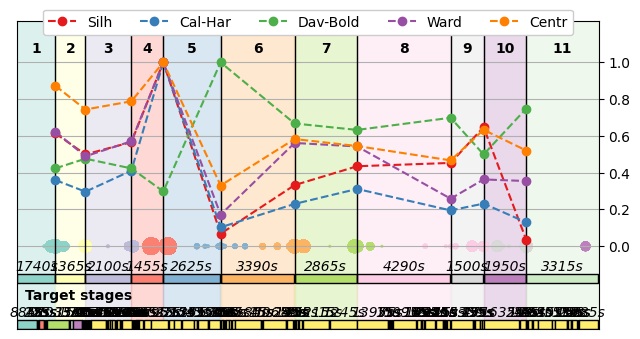

In [209]:
result = analyze(features, 15, "topological")

### Традиционные признаки

In [210]:
def read_traditional():
    df_ft_psd_loc_db = pandas.read_feather(f'{subj}/{exp}/traditional_features/df_ft_psd_loc_db.feather')
    df_ft_psd_ind_loc_log = pandas.read_feather(f'{subj}/{exp}/traditional_features/df_ft_psd_ind_loc_log.feather')
    df_ft_coh_ind_loc = pandas.read_feather(f'{subj}/{exp}/traditional_features/df_ft_coh_ind_loc.feather')
    df_ft_plv_ind_loc = pandas.read_feather(f'{subj}/{exp}/traditional_features/df_ft_plv_ind_loc.feather')

    result =  pandas.concat([
        df_ft_psd_loc_db,
        df_ft_psd_ind_loc_log,
        df_ft_coh_ind_loc,
        df_ft_plv_ind_loc
    ], axis = 1).fillna(0)

    return result

(1784, 357)
(1784, 15)
Explained variance 0.92
[np.float64(0.228), np.float64(0.188), np.float64(0.129), np.float64(0.074), np.float64(0.057), np.float64(0.041), np.float64(0.037), np.float64(0.033), np.float64(0.029), np.float64(0.024), np.float64(0.022), np.float64(0.018), np.float64(0.016), np.float64(0.016), np.float64(0.012)]
Applying to 1784 samples with 15 features each


stage 2: 100%|██████████| 672/672 [00:19<00:00, 34.56it/s]


,St_len_min,K_nb_max,N_cl_max,Cl_cen,Len_min,St_edges,N_stages,Longest_stage,Shortest_stage,Avg_stage_length,...,Cen_dist,Silh,Cal-Har,Dav-Bold,Avg-Silh,Avg-Cal-Har,Avg-Dav-Bold,AMI,ARI,FMI
0,40,50,15,Mode,40,"[0, 44, 297, 343, 567, 665, 875, 950, 1066, 13...",11,280,44,162.181818,...,2.018036,-0.057846,3.893944,12.894926,0.05592,5.391844,7.55198,0.920504,0.907717,0.918245


array([   0,   44,  297,  343,  567,  665,  875,  950, 1066, 1346, 1540,
       1784])

,0,1,2,3,4,5,6,7,8,9,10
"Start-end time, sec","(25230.0, 25875.0)","(25890.0, 29670.0)","(29685.0, 30360.0)","(30375.0, 33720.0)","(33735.0, 35190.0)","(35205.0, 38340.0)","(38355.0, 39465.0)","(39480.0, 41205.0)","(41220.0, 45405.0)","(45420.0, 48315.0)","(48330.0, 51975.0)"
"Time length, sec",645.0,3780.0,675.0,3345.0,1455.0,3135.0,1110.0,1725.0,4185.0,2895.0,3645.0
Number of epochs,44,253,46,224,98,210,75,116,280,194,244


{'St_len_min': 40,
 'K_nb_max': 50,
 'N_cl_max': 15,
 'Cl_cen': 'Mode',
 'Len_min': 40,
 'St_edges': array([   0,   44,  297,  343,  567,  665,  875,  950, 1066, 1346, 1540,
        1784]),
 'N_stages': 11,
 'Longest_stage': 280,
 'Shortest_stage': 44,
 'Avg_stage_length': 162.1818181818182,
 'Ward_dist': 238.06390648742476,
 'Cen_dist': 2.0180361932904374,
 'Silh': -0.057845714270205476,
 'Cal-Har': 3.8939444360179745,
 'Dav-Bold': 12.894926196306729,
 'Avg-Silh': 0.05591996087312413,
 'Avg-Cal-Har': 5.391843854304879,
 'Avg-Dav-Bold': 7.551979878253375,
 'AMI': 0.9205040972198315,
 'ARI': 0.9077168491954516,
 'FMI': 0.9182451660293981}

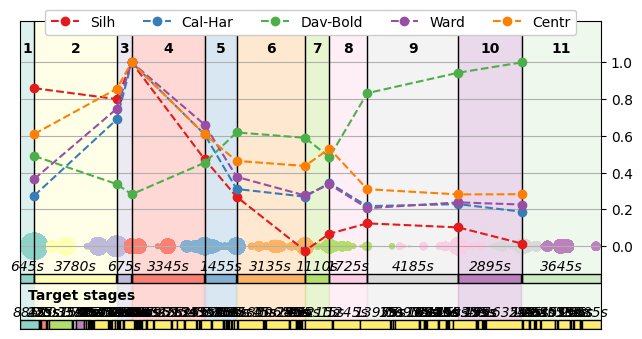

In [211]:
analyze(read_traditional(), 15, "traditional")